In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

sys.path.append('..')

from model import *
from utils import *
from dataset import *
from train import *

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = sc.read_h5ad('./data/perturb_filtered_gbm_crispri_crop.h5ad')

#remove treatment NA
na_rows = data.obs[data.obs['treatment'] == 'NA']
data = data[~data.obs.index.isin(na_rows.index)].copy()
data.obs['library_size'] = data.X.sum(axis=1)

In [3]:
#sc.pp.normalize_total(data)
#sc.pp.log1p(data)
#sc.pp.pca(data)

#sc.pp.neighbors(data)
#sc.tl.umap(data)

In [4]:
#sc.pl.umap(data, color=['treatment', 'top_sg'], size=10)

In [5]:
percentile_99 = np.percentile(data.obs['library_size'], 99)
data = data[data.obs['library_size'] <= percentile_99].copy()

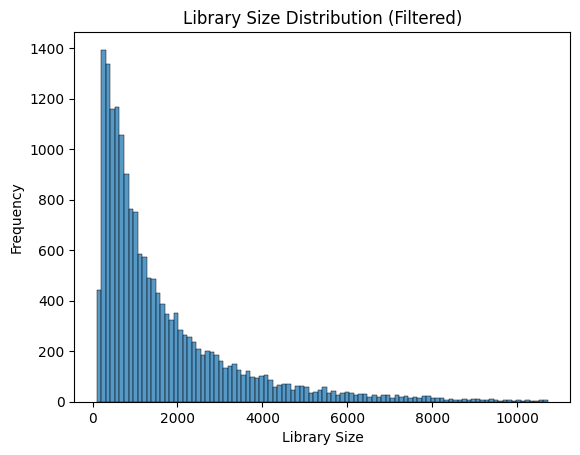

In [6]:
sns.histplot(data.obs['library_size'], bins=100)
plt.xlabel('Library Size')
plt.ylabel('Frequency')
plt.title('Library Size Distribution (Filtered)')
plt.show()

In [9]:
dataset = PerturbDataset(data)

In [10]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)

# # Example: Iterate through the DataLoader
# for X, P, C in dataloader:
#     print("Batch X shape:", X.shape)
#     print("Batch P:", P)
#     print("Batch C:", C)
#     break

In [11]:
%load_ext autoreload
%autoreload 2

In [12]:
# ----------------------------------------------------------------------
# 1. GLOBAL DEBUG SWITCHES
# ----------------------------------------------------------------------
import warnings, math, functools, inspect, builtins
import pyro, torch

torch.autograd.set_detect_anomaly(True)          # traces op that first returns NaN / Inf
pyro.enable_validation(True)                     # Pyro distributions raise on bad params

def _dbg(name, t):
    """Print shape/range + assert finite."""
    if isinstance(t, torch.Tensor):
        if not torch.isfinite(t).all():
            bad = t[~torch.isfinite(t)]
            print(f"[NaN‑DEBUG] {name} has {bad.numel()} non‑finite values. "
                  f"Min={bad.min().item() if bad.numel() else 'NA'} "
                  f"Max={bad.max().item() if bad.numel() else 'NA'} "
                  f"Example={bad.flatten()[0].item() if bad.numel() else 'NA'}")
            raise ValueError(f"NaN or Inf detected in {name}")
        else:
            # comment‑out next line if it is too chatty
            print(f"[OK] {name:15s}  shape={tuple(t.shape)} "
                  f"range=({t.min().item():.3g}, {t.max().item():.3g})")
    return t
# ----------------------------------------------------------------------


In [77]:
import pyro
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import torch

import pyro.distributions as dist
import torch.nn as nn
from tqdm import tqdm 
from sklearn.metrics import r2_score
from model_simple import VAE



# Initialize the VAE
pyro.clear_param_store()

input_dim = data.shape[-1] 
latent_dim = 16
vae = VAE(input_dim, latent_dim, 
               len(np.unique(dataset.P_indices)),
                 len(np.unique(dataset.C_indices)),
                 100, 5.0)
vae = vae.to(vae.device)

# Optimizer and SVI
optimizer = Adam({"lr": 5e-4})
svi = SVI(vae.model, vae.guide, optimizer, loss=Trace_ELBO())

# Example training loop
print("Training VAE...", vae.device)
num_epochs = 10
losses = []

for epoch in range(num_epochs):
    epoch_loss = 0
    all_actuals = []
    all_predictions = []
    cls_loss = 0
    for X, P, C in tqdm(dataloader, desc=f"Epoch {epoch + 1}/{num_epochs}", leave=False):
        # Move data to the same device as the model
        X = X.to(vae.device).float()
        P = P.to(vae.device).int()
        C = C.to(vae.device).int()
        
        loss = svi.step(X, P, C)
        epoch_loss += loss
        losses.append(loss)
        
        with torch.no_grad(), poutine.trace() as tr:
            vae.model(X, P, C)         
        node = tr.trace.nodes.get("cls_p")
        cls_loss += node["fn"].log_factor[0]
        
        with torch.no_grad():
            z_loc, _ = vae.z_encoder(torch.cat([X,vae.p_emb(P)], dim=-1)).chunk(2, dim=-1)  # Latent space
            decoded_logits = vae.z_decoder(z_loc)               # Reconstructed data
            mu = torch.softmax(decoded_logits, dim=-1)
            total_counts = X.sum(-1, keepdim=True)
            x_mu = total_counts * mu

            all_actuals.append(X.cpu().numpy())
            all_predictions.append(x_mu.cpu().numpy())

    # Calculate R² at the end of the epoch
    all_actuals = np.concatenate(all_actuals, axis=0)
    all_predictions = np.concatenate(all_predictions, axis=0)
    r2 = r2_score(all_actuals.flatten(), all_predictions.flatten())
    
    # print(f"Epoch {epoch + 1}, Loss: {epoch_loss / dataset.X.shape[0]:.4f}, R²: {r2:.4f}")
    print(f"Epoch {epoch + 1}, Loss: {epoch_loss / dataset.X.shape[0]:.4f}, R²: {r2:.4f}, Classification Loss: {cls_loss:.4f}")

Training VAE... cuda


Epoch 1, Loss: 2698.5677, R²: 0.4898, Classification Loss: -83175.4844


Epoch 2, Loss: 2487.6396, R²: 0.6579, Classification Loss: -83047.2188


Epoch 3, Loss: 2442.4832, R²: 0.6763, Classification Loss: -92686.2812


Epoch 4, Loss: 2362.2509, R²: 0.6865, Classification Loss: -148455.8125


...

Epoch 6, Loss: 2172.9165, R²: 0.6995, Classification Loss: -396102.5625


Epoch 7, Loss: 2093.2426, R²: 0.7064, Classification Loss: -558923.0625


Epoch 8, Loss: 2041.4538, R²: 0.7080, Classification Loss: -706663.7500


Epoch 9, Loss: 1998.9450, R²: 0.7103, Classification Loss: -818625.5000


Epoch 10, Loss: 1966.2531, R²: 0.7115, Classification Loss: -936487.3125


In [78]:
vae.total_counts.max()

np.float32(7402.0)

In [79]:
import pyro.poutine as poutine
model = vae
model.device = torch.device('cpu')
model.eval()
model = model.to(model.device)


X, P, C = torch.tensor(dataset.X), torch.tensor(dataset.P_indices), torch.tensor(dataset.C_indices)

trace = poutine.trace(model.guide).get_trace(X, P, C)
trace_model = poutine.trace(model.model).get_trace(X, P, C)

In [80]:
z = trace.nodes["z"]["value"]
mu = model.z_decoder(z)

l = X.sum(axis=-1, keepdim=True)
mu = torch.softmax(mu, dim=-1)
prediction = l * mu

In [81]:
correct = 0
total   = 0

logits = model.z_prediction_head(z) 
y_pred = logits.argmax(dim=-1) 
correct += (y_pred == P).sum().item()
total   += P.size(0)

accuracy = correct / total
print(f"Classification accuracy: {accuracy:.4f}")

Classification accuracy: 0.6128


/home/jm5707/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


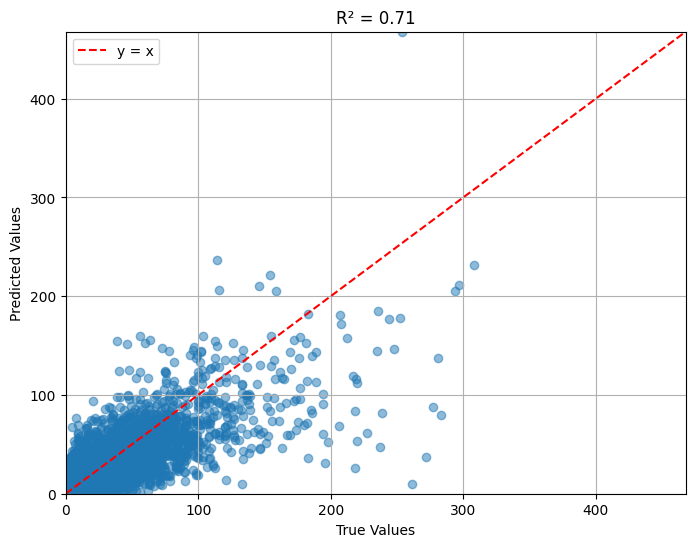

In [82]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

r2 = r2_score(dataset.X.flatten(), prediction.flatten().detach().numpy())

idx = np.arange(0, dataset.X.shape[0])
np.random.shuffle(idx)
idx = idx[:1000]

true_vals = dataset.X[idx].flatten()
pred_vals = prediction.detach().numpy()[idx].flatten()

# Scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(true_vals, pred_vals, alpha=0.5)

# y = x line
min_val = min(true_vals.min(), pred_vals.min())
max_val = max(true_vals.max(), pred_vals.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

# Equal axis scaling
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"R² = {r2:.2f}")
plt.grid(True)
plt.legend()
plt.show()


In [83]:
rho = trace.nodes["rho"]["value"]
print(rho.shape)
#rho_at_P = rho[batch_indices, P, :]  # shape: [batch, latent_dim]

#data.obsm['rho'] = rho_at_P.detach().cpu().numpy()


torch.Size([100, 16])


In [84]:
z = trace.nodes["z"]["value"]
z0 = trace.nodes["z0"]["value"]

In [85]:
z_data = data.copy()
z_data.obsm['z'] = z.detach().cpu().numpy()
sc.pp.neighbors(z_data, use_rep='z', n_neighbors=15)
sc.tl.umap(z_data)

In [86]:
z0_data = data.copy()
z0_data.obsm['z0'] = z0.detach().cpu().numpy()
sc.pp.neighbors(z0_data, use_rep='z0', n_neighbors=15)
sc.tl.umap(z0_data)

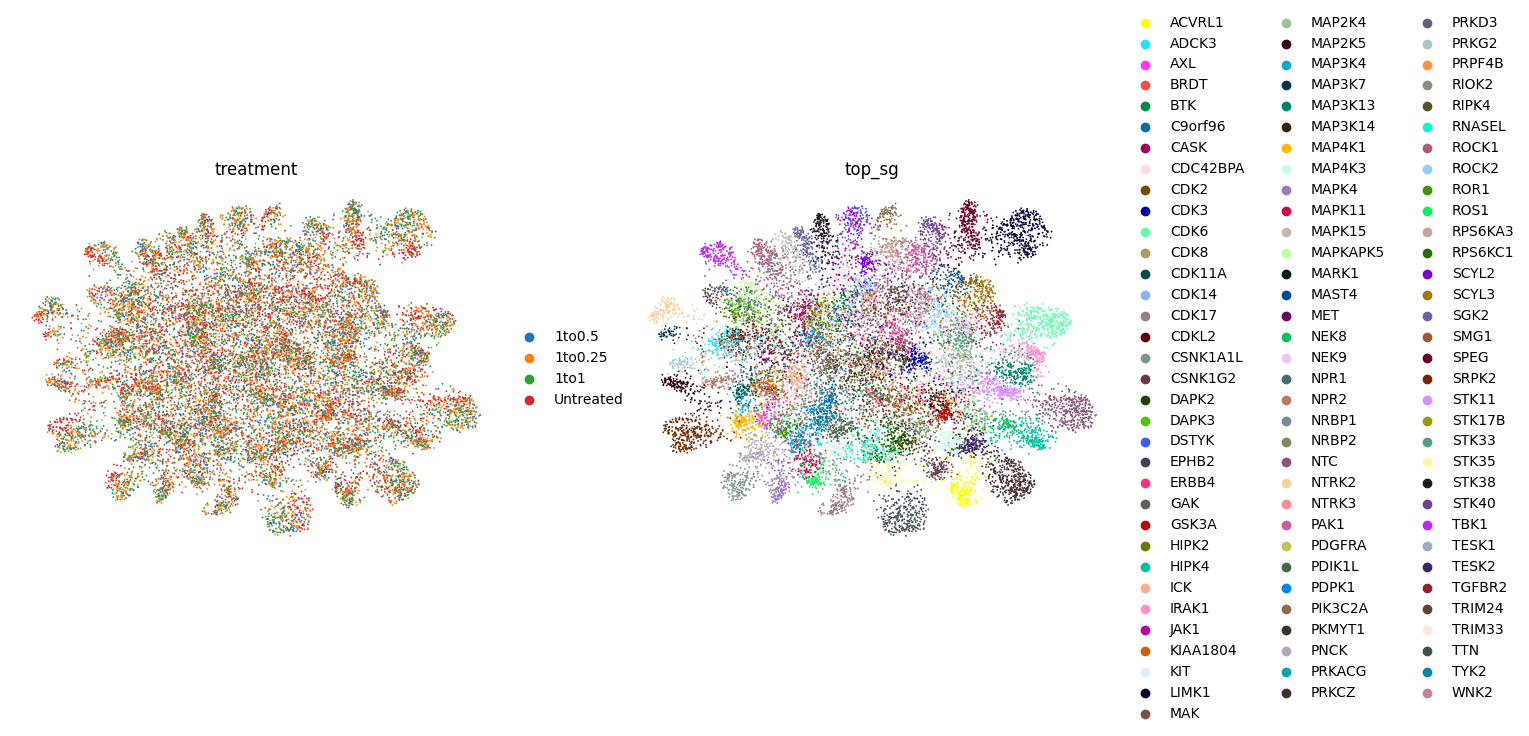

In [87]:
sc.pl.umap(z_data, color=['treatment', 'top_sg'], frameon=False, show=True)

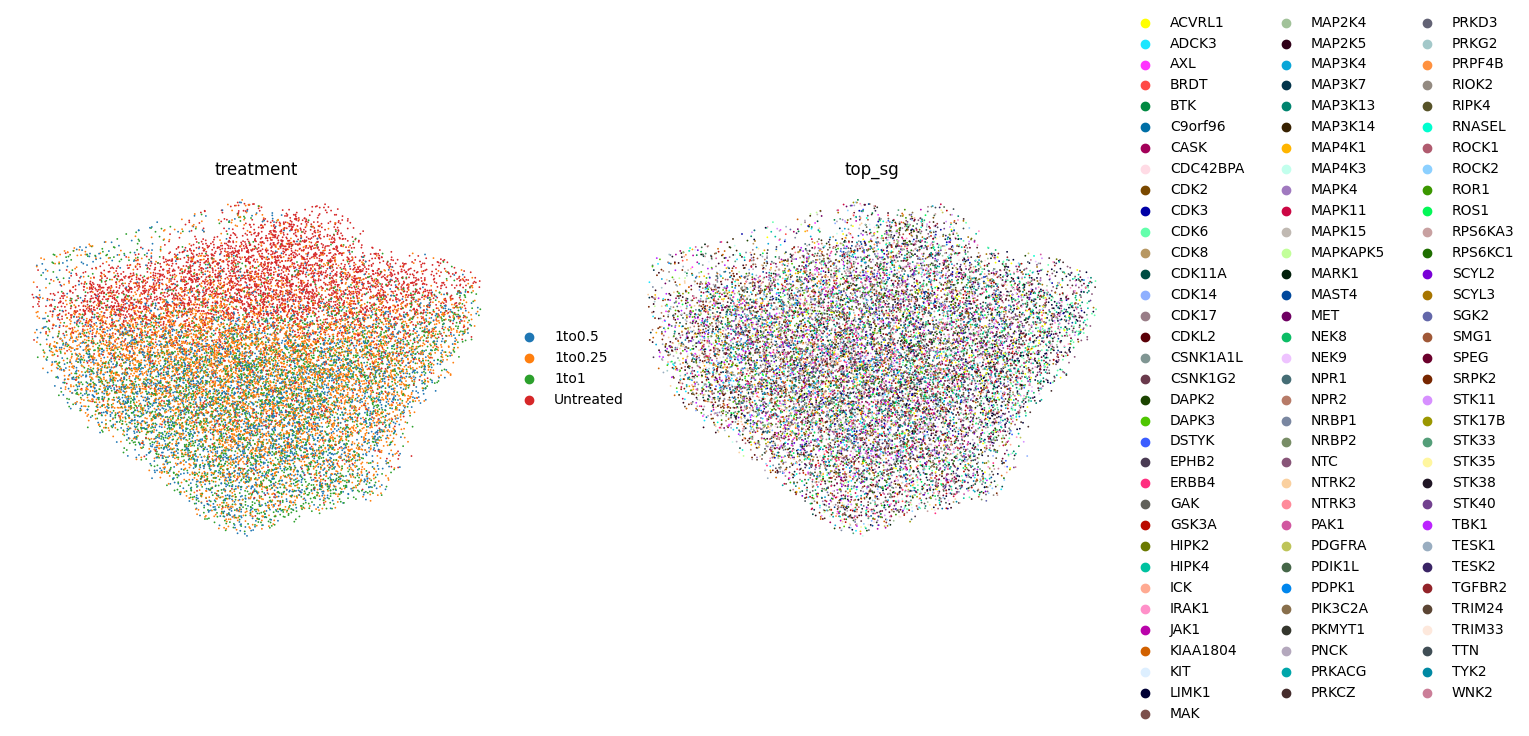

In [88]:
sc.pl.umap(z0_data, color=['treatment', 'top_sg'], frameon=False, show=True)

In [89]:
s_gate = trace.nodes["s_gate"]['value']
rho = trace.nodes['rho']['value'].detach().cpu()
A = model.rho_dec(rho)/math.sqrt(model.latent_dim)  # (P,d)
W = A.detach().cpu().numpy()*s_gate.detach().cpu().numpy()  # (P,d)

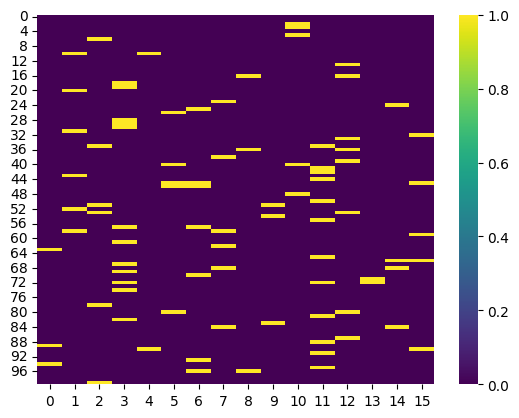

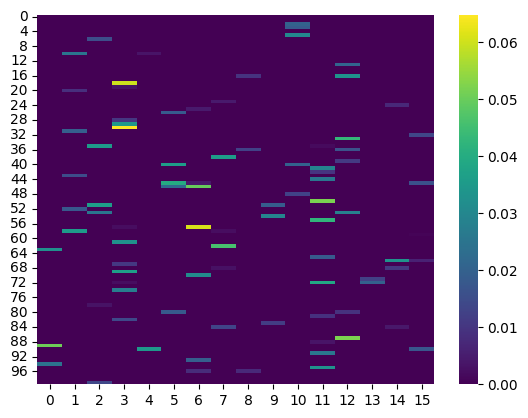

In [90]:
sns.heatmap(s_gate.detach().cpu().numpy(), cmap='viridis')
plt.show()
sns.heatmap(np.abs(W), cmap='viridis')
plt.show()

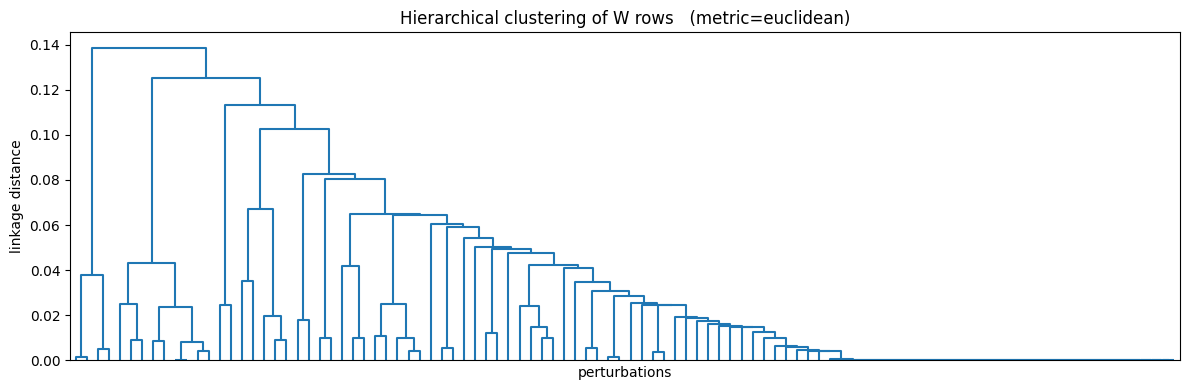

In [91]:
import numpy as np, pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

W_norm = (W - W.mean(0)) / W.std(0, ddof=1)


metric  = "euclidean"  # 'euclidean', 'cosine', 'correlation'
dist_mat = pdist(W, metric=metric)    

link = linkage(dist_mat, method="ward")

plt.figure(figsize=(12, 4))
dendrogram(link, no_labels=True, color_threshold=0.0, count_sort=True)
plt.title(f"Hierarchical clustering of W rows   (metric={metric})")
plt.xlabel("perturbations")
plt.ylabel("linkage distance")
plt.tight_layout()
plt.show()

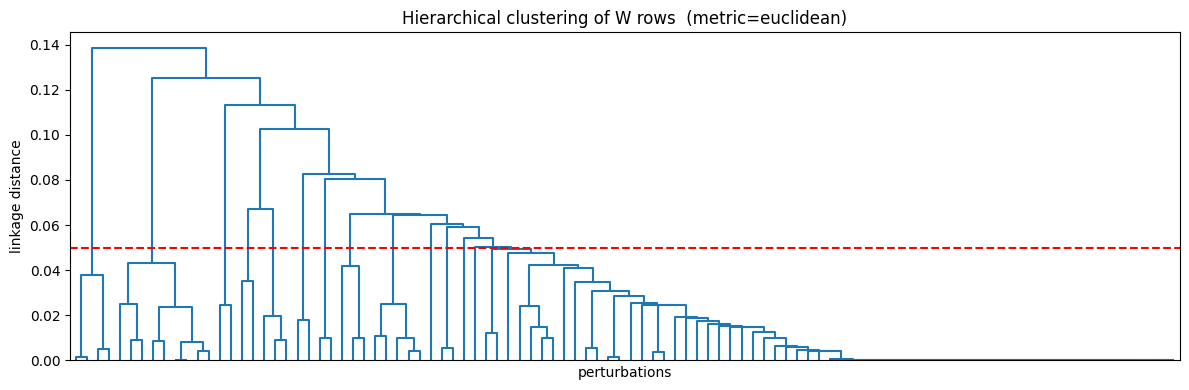


Cluster 1  (n=4)
   • DAPK2
   • JAK1
   • KIAA1804
   • PRPF4B

Cluster 2  (n=9)
   • MAP4K3
   • MAPK11
   • MAPK4
   • NEK9
   • NTC
   • PRKACG
   • RNASEL
   • TBK1
   • TRIM24

Cluster 3  (n=2)
   • MARK1
   • NTRK3

Cluster 4  (n=3)
   • CSNK1A1L
   • MAK
   • STK33

Cluster 5  (n=2)
   • NPR1
   • NRBP1

Cluster 6  (n=2)
   • PKMYT1
   • STK38

Cluster 7  (n=2)
   • MAP3K4
   • PIK3C2A

Cluster 8  (n=3)
   • AXL
   • C9orf96
   • MAP4K1

Cluster 9  (n=5)
   • CDK17
   • DSTYK
   • KIT
   • MAPK15
   • PAK1

Cluster 10  (n=2)
   • PDPK1
   • ROCK2

Cluster 11  (n=63)
   • ACVRL1
   • ADCK3
   • BRDT
   • BTK
   • CASK
   • CDC42BPA
   • CDK11A
   • CDK14
   • CDK2
   • CDK3
   • CDK6
   • CDK8
   • CDKL2
   • CSNK1G2
   • DAPK3
   • EPHB2
   • ERBB4
   • GAK
   • GSK3A
   • HIPK2
   • HIPK4
   • ICK
   • IRAK1
   • LIMK1
   • MAP2K4
   • MAP3K13
   • MAP3K14
   • MAP3K7
   • MAST4
   • MET
   • NEK8
   • NPR2
   • NRBP2
   • NTRK2
   • PDGFRA
   • PDIK1L
   • PNCK
   • PRKCZ
  

In [92]:

thresh = 0.05

plt.figure(figsize=(12, 4))
dendrogram(link, no_labels=True, color_threshold=0.0, count_sort=True)

plt.axhline(y=thresh, color="red", linestyle="--", linewidth=1.5)

plt.title(f"Hierarchical clustering of W rows  (metric={metric})")
plt.xlabel("perturbations")
plt.ylabel("linkage distance")
plt.tight_layout()
plt.show()

clusters = fcluster(link, thresh, criterion="distance")

idx_to_name = {idx: name for name, idx in dataset.perturbation_dict.items()}

grouped = {}                             # cluster_id -> list[str]
for idx, c in enumerate(clusters):
    grouped.setdefault(c, []).append(idx_to_name[idx])

for c_id, names in sorted(grouped.items()):
    print(f"\nCluster {c_id}  (n={len(names)})")
    for n in names:
        print("   •", n)
